In [1]:
h1=1
m=0.5
import numpy as np                                                        #  matrix coupling
def coupling(matrix_1,matrix_2):                                 
    s11_1=matrix_1[0][0]
    s12_1=matrix_1[0][1]
    s21_1=matrix_1[1][0]
    s22_1=matrix_1[1][1]
    s11_2=matrix_2[0][0]
    s12_2=matrix_2[0][1]
    s21_2=matrix_2[1][0]
    s22_2=matrix_2[1][1]
    s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
    s12=s12_1*s12_2/(1-s11_2*s22_1)
    s21=s21_2*s21_1/(1-s11_2*s22_1)
    s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
    result = np.array([[s11, s12], [s21, s22]], np.complex128)
    return result                                                   
def multiple_coupling(matrix_collect_1):                                  #  multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2

def coupling_matrix_of_N_modified(E,y1,y2,N,n3,n4,a):     #coupling_matrix_of_N    N is period  (n3 is +)  (n3 is -)
    constant_1=2*m*(y1+1j*y2)/(h1**2)
    constant_2=2*m*(y1-1j*y2)/(h1**2)
    di=np.zeros((2*N+n3+n4),dtype=complex)
    for i in np.arange(2*N+n3+n4):
        if i<(2*N):
            if i%2==0:
                di[i]=constant_1
            if i%2==1:
                di[i]=constant_2
        if i>=(2*N) and i<(2*N+n3):
            di[i]=constant_1
        if i>=(2*N+n3):
            di[i]=constant_2
   # print(di)
    x_0=0
    x_1=a*(2*N+n3+n4)-a+x_0
    location = np.linspace(x_0, x_1, 2*N+n3+n4)          #n4 is (Sum of Plus first potential)
#    print(location)
    k=(E*2*m)**0.5/(h1)
    matrix_collect = np.zeros((2*N+n3+n4, 2, 2), dtype=complex)
    for i in np.arange(2*N+n3+n4):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
 #       if i==len(np.arange(2*N+n3+n4))-1:
#         s12=0
    #        s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
    print(matrix_collect)
    return matrix_6
def Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4,a):
    return float(abs(coupling_matrix_of_N_modified(E,y1,y2,N,n3,n4,a)[1][0]**2))
def Reflection_coefficient_of_N_modified(E,y1,y2,N,n3,n4,a):
    return float(abs(coupling_matrix_of_N_modified(E,y1,y2,N,n3,n4,a)[0][0]**2))

In [42]:
a=0.5
E=1
y1=1
y2=1
N=2
n3=0
n4=0
print(Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4,a))#,Reflection_coefficient_of_N_modified(E,y1,y2,N,n3,n4,a))
#print(Transmission_coefficient_of_N_modified(1,1,1,1,0,0),Reflection_coefficient_of_N_modified(1,1,1,1,0,0))
#print(Transmission_coefficient_of_N_modified(1,0,1,0,1,1),Reflection_coefficient_of_N_modified(1,0,1,0,1,1))

[[[-0.        -1.j          1.        -1.j        ]
  [ 1.        -1.j         -0.        -1.j        ]]

 [[-0.04782673-0.44464886j  0.6       -0.2j       ]
  [ 0.6       -0.2j        -0.38441512+0.22852793j]]

 [[ 0.90929743+0.41614684j  1.        -1.j        ]
  [ 1.        -1.j         -0.90929743+0.41614684j]]

 [[ 0.424221  +0.1415505j   0.6       -0.2j       ]
  [ 0.6       -0.2j         0.367773  +0.2544465j ]]]
0.056358248005690725


In [28]:
print(np.linspace(0, 3, 7))        #n4 is (Sum of Plus first potential)

[0.  0.5 1.  1.5 2.  2.5 3. ]


In [37]:
import numpy as np

h1 = 1
m = 0.5

def coupling(matrix_1, matrix_2):
    s11_1, s12_1 = matrix_1[0, 0], matrix_1[0, 1]
    s21_1, s22_1 = matrix_1[1, 0], matrix_1[1, 1]
    s11_2, s12_2 = matrix_2[0, 0], matrix_2[0, 1]
    s21_2, s22_2 = matrix_2[1, 0], matrix_2[1, 1]
    
    denom = 1 - s11_2 * s22_1
    s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
    s12 = s12_1 * s12_2 / denom
    s21 = s21_2 * s21_1 / denom
    s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom
    
    return np.array([[s11, s12], [s21, s22]], dtype=np.complex128)

def multiple_coupling(matrix_collect):
    result = matrix_collect[0]
    for matrix in matrix_collect[1:]:
        result = coupling(result, matrix)
    return result

def coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a):
    constant_1 = 2 * m * (y1 + 1j * y2) / (h1**2)
    constant_2 = 2 * m * (y1 - 1j * y2) / (h1**2)
    
    di = np.array([constant_1 if i % 2 == 0 or i >= 2 * N and i < 2 * N + n3 else constant_2 
                   for i in range(2 * N + n3 + n4)], dtype=complex)
    
    x_0 = 0
    x_1 = a * (2 * N + n3 + n4) - a + x_0
    location = np.linspace(x_0, x_1, 2 * N + n3 + n4)
 #   print(location)
    k = np.sqrt(E * 2 * m) / h1
    exp_2jk = np.exp(2j * k * location)
    exp_minus_2jk = np.exp(-2j * k * location)
    
    matrix_collect = np.zeros((2 * N + n3 + n4, 2, 2), dtype=complex)
    for i in range(2 * N + n3 + n4):
        s11 = di[i] * exp_2jk[i]
        s12 = 2j * k
        s21 = 2j * k
        s22 = di[i] * exp_minus_2jk[i]
        
        matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
  #  print(matrix_collect)
    return multiple_coupling(matrix_collect)

def Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[1, 0])**2)

def Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[0, 0])**2)

In [8]:
a=0.2
E=1
y1=1
y2=1
N=2
n3=1
n4=0
print(Transmission_coefficient_of_N_modified(E,y1,y2,N,n3,n4,a))

0.059486140810796305


In [24]:
# 绘图参数        最终
N = 100
n3 = 0
n4 = 0
y11 = [2]  # y1 的不同取值
y22 = [2]     # y2 的不同取值
a = 0.5
zhi_1 = ['T']  # 选择绘制 T（透射系数）

# 能量范围
E_ranges = [(0, 400)]  # 可以分段计算

# 输出文件夹
folder_name = "T&R实数与虚数_kan"
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)

# 确保输出目录存在
try:
    os.makedirs(output_dir, exist_ok=True)
    print(f"文件夹 '{output_dir}' 已创建或已存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 遍历每个能量范围
for range_idx, (E_min, E_max) in enumerate(E_ranges):
    # 动态子图布局
    num_rows = len(y11)
    num_cols = len(y22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)

    # 处理单行/单列情况
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])
    elif num_rows == 1:
        axes = axes.reshape(1, -1)
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)

    # 遍历 y11 和 y22 的组合
    for i, y1 in enumerate(y11):
        for j, y2 in enumerate(y22):
            E_values = np.linspace(E_min, E_max, 1000)
            T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            Sum_values = [T + R for T, R in zip(T_values, R_values)]

            ax = axes[i, j]
            if 'T' in zhi_1:
                ax.plot(E_values, T_values, label='Transmission (T)', color='blue')
            if 'R' in zhi_1:
                ax.plot(E_values, R_values, label='Reflection (R)', color='red')
            if 'T+R' in zhi_1:
                ax.plot(E_values, Sum_values, label='T + R', color='green', linestyle='--')

            ax.set_xlabel('Energy (E)')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'y1={y1}, y2={y2}')
            ax.legend()
            ax.grid(True)
            ax.set_xlim(E_min, E_max)
            ax.set_ylim(0, 20)

    plt.tight_layout()

    # 保存图片
    y11_str = '_'.join(map(str, y11))
    y22_str = '_'.join(map(str, y22))
    zhi1_str = '_'.join(zhi_1)
    output_filename = os.path.join(
        output_dir,
        f'{range_idx + 1}_T&R({E_min},{E_max})_N={N}_n3={n3}_n4={n4}_y11={y11_str}_y22={y22_str}_a={a}_zhi1={zhi1_str}.png'
    )
    plt.savefig(output_filename, dpi=300)
    plt.close()
    print(f"已保存: {output_filename}")

文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_n' 已创建或已存在


C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:15: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数_n\1_T&R(0,400)_N=1_n3=0_n4=0_y11=2_4_y22=2_a=0.5_zhi1=T.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
# 绘图参数
N = 10
n3 = 0
n4 = 0
y11 = [2, 4]  # y1 的不同取值
y22 = [2]     # y2 的不同取值
a = 0.5
zhi_1 = ['T']  # 选择绘制 T（透射系数）

# 能量范围
E_ranges = [(0, 400)]  # 可以分段计算

# 输出文件夹
folder_name = "T&R实数与虚数"
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)

# 确保输出目录存在
try:
    os.makedirs(output_dir, exist_ok=True)
    print(f"文件夹 '{output_dir}' 已创建或已存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 遍历每个能量范围
for range_idx, (E_min, E_max) in enumerate(E_ranges):
    # 动态子图布局
    num_rows = len(y11)
    num_cols = len(y22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)

    # 处理单行/单列情况
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])
    elif num_rows == 1:
        axes = axes.reshape(1, -1)
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)

    # 遍历 y11 和 y22 的组合
    for i, y1 in enumerate(y11):
        for j, y2 in enumerate(y22):
            E_values = np.linspace(E_min, E_max, 1000)
            T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            Sum_values = [T + R for T, R in zip(T_values, R_values)]

            ax = axes[i, j]
            if 'T' in zhi_1:
                ax.plot(E_values, T_values, label='Transmission (T)', color='blue')
            if 'R' in zhi_1:
                ax.plot(E_values, R_values, label='Reflection (R)', color='red')
            if 'T+R' in zhi_1:
                ax.plot(E_values, Sum_values, label='T + R', color='green', linestyle='--')

            ax.set_xlabel('Energy (E)')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'y1={y1}, y2={y2}')
            ax.legend()
            ax.grid(True)
            ax.set_xlim(E_min, E_max)
            ax.set_ylim(0, 4)

    plt.tight_layout()

    # 保存图片
    y11_str = '_'.join(map(str, y11))
    y22_str = '_'.join(map(str, y22))
    zhi1_str = '_'.join(zhi_1)
    output_filename = os.path.join(
        output_dir,
        f'{range_idx + 1}_T&R({E_min},{E_max})_N={N}_n3={n3}_n4={n4}_y11={y11_str}_y22={y22_str}_a={a}_zhi1={zhi1_str}.png'
    )
    plt.savefig(output_filename, dpi=300)
    plt.close()
    print(f"已保存: {output_filename}")

文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数' 已创建或已存在


C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:15: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数\1_T&R(0,400)_N=10_n3=0_n4=0_y11=2_4_y22=2_a=0.5_zhi1=T.png


In [8]:
import os         #最终 a的变化
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
N = 100
n3 = 0
n4 = 0
y11 = [0]  # 修改为 [2]
y22 = [2]  # 修改为 [0]
a_1 = [100]#np.linspace(0.1, 1, 10)
zhi_1 = ['T', 'R', 'T+R']  # 动态选择绘制的曲线

# 定义能量范围和分段
E_ranges = [(0, 400)]  # 分为五段

# 动态生成文件夹名称
folder_name = f'T&R实数与虚数_a的变化'  # folder_name = f'T&R(real={y11},imag={y22})'
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)

# 确保目录存在
try:
    os.makedirs(output_dir)
    print(f"文件夹 '{output_dir}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{output_dir}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")
for a in a_1:
    # 遍历每个能量范围
    for range_idx, (E_min, E_max) in enumerate(E_ranges):
        # 创建动态子图布局
        num_rows = len(y11)
        num_cols = len(y22)
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))  # 动态调整子图大小
        fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)  # 总标题
    
        # 如果 num_rows 或 num_cols 为 1，将 axes 转换为二维数组以便统一处理
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])  # 单个子图，转换为二维数组
        elif num_rows == 1:
            axes = axes.reshape(1, -1)  # 只有一行，转换为二维数组
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)  # 只有一列，转换为二维数组
    
        # 遍历 y11 和 y22 的值
        for i, y1 in enumerate(y11):
            for j, y2 in enumerate(y22):
                # 生成能量值
                E_values = np.linspace(E_min, E_max, 1000)  # E 从 E_min 到 E_max，取 500 个点
    
                # 计算传输系数和反射系数
                T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
                R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
                Sum_values = [T + R for T, R in zip(T_values, R_values)]
    
                # 获取当前子图
                ax = axes[i, j]
    
                # 根据 zhi_1 的值动态绘制曲线
                if 'T' in zhi_1:
                    ax.plot(E_values, T_values, label='Transmission Coefficient', color='blue')
                if 'R' in zhi_1:
                    ax.plot(E_values, R_values, label='Reflection Coefficient', color='red')
                if 'T+R' in zhi_1:
                    ax.plot(E_values, Sum_values, label='Transmission + Reflection', color='green', linestyle='--')
    
                # 设置子图属性
                ax.set_xlabel('Energy (E)')
                ax.set_ylabel('Coefficient Value')
                ax.set_title(f'y1={y1}, y2={y2}')
                ax.legend()
                ax.grid(True)
                ax.set_xlim(E_min, E_max)  # x 轴范围
                ax.set_ylim(0, 4)  # y 轴范围限定在 0 到 1.5 之间
    
        plt.tight_layout()  # 调整子图布局
    
        # 将 y11 和 y22 转换为字符串
        y11_str = '_'.join(map(str, y11))
        y22_str = '_'.join(map(str, y22))
        zhi1_str = '_'.join(zhi_1)  # 将 zhi_1 转换为字符串
    
        # 保存图像
        output_filename = os.path.join(
            output_dir,
            f'{range_idx + 1}_T&R({E_min},{E_max})_N={N}_n3={n3}_n4={n4}_y11={y11_str}_y22={y22_str}_a={a}_zhi1={zhi1_str}.png'
        )
        plt.savefig(output_filename, dpi=300)  # 保存为高分辨率图像
        plt.close()  # 关闭图形以释放内存
    
        print(f'Saved: {output_filename}')  # 打印保存路径

文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_a的变化' 已经存在


C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:15: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


Saved: C:\Users\taoji\Desktop\结果\T&R实数与虚数_a的变化\1_T&R(0,400)_N=100_n3=0_n4=0_y11=0_y22=2_a=100_zhi1=T_R_T+R.png


In [14]:
%matplotlib inline

In [12]:
%matplotlib qt

---------y1=4,y2=0------------


C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:15: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


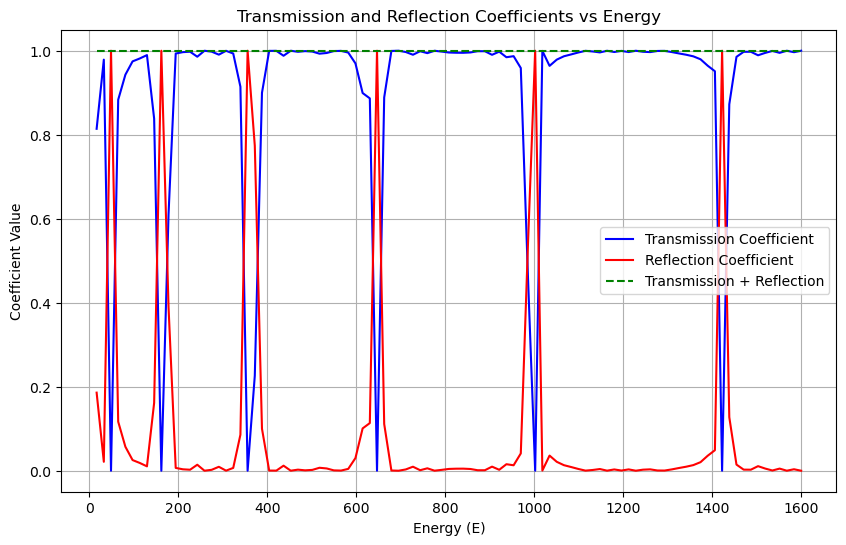

In [45]:
y1=4
y2=0
N=100
n3=0
n4=0
a=0.5
print(f'---------y1={y1},y2={y2}------------')
E_values = np.linspace(0, 1600, 100)
T_values = []
R_values = []
for E in E_values :
    T_values.append(Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4,a))
    R_values.append(Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4,a))
Sum_values = [T + R for T, R in zip(T_values, R_values)]

plt.figure(figsize=(10, 6))
plt.plot(E_values, T_values, label='Transmission Coefficient', color='blue')
plt.plot(E_values, R_values, label='Reflection Coefficient', color='red')
plt.plot(E_values, Sum_values, label='Transmission + Reflection', color='green', linestyle='--')

# 设置图像属性
plt.xlabel('Energy (E)')
plt.ylabel('Coefficient Value')
plt.title('Transmission and Reflection Coefficients vs Energy')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
import os               ###### 结果 T&R
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
N = 100
n3 = 0
n4 = 0
y11 = [0,0.2,0.4]
y22 = [0,0.2,0.4]
a=0.5

# 定义能量范围和分段
E_ranges = [(0, 400)]  # 分为五段

# 动态生成文件夹名称
folder_name = f'T&R实数与虚数'#folder_name = f'T&R(real={y11},imag={y22})'
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)

# 确保目录存在
try:
    os.makedirs(output_dir)
    print(f"文件夹 '{output_dir}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{output_dir}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 遍历每个能量范围
for range_idx, (E_min, E_max) in enumerate(E_ranges):
    # 创建动态子图布局
    num_rows = len(y11)
    num_cols = len(y22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))  # 动态调整子图大小
    fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)  # 总标题

    # 遍历 y11 和 y22 的值
    for i, y1 in enumerate(y11):
        for j, y2 in enumerate(y22):
            # 生成能量值
            E_values = np.linspace(E_min, E_max, 500)  # E 从 E_min 到 E_max，取 500 个点

            # 计算传输系数和反射系数
            T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4,a) for E in E_values]
            R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4,a) for E in E_values]
            Sum_values = [T + R for T, R in zip(T_values, R_values)]

            # 在当前子图中绘制图像
            ax = axes[i, j]
            ax.plot(E_values, T_values, label='Transmission Coefficient', color='blue')
            ax.plot(E_values, R_values, label='Reflection Coefficient', color='red')
            ax.plot(E_values, Sum_values, label='Transmission + Reflection', color='green', linestyle='--')

            # 设置子图属性
            ax.set_xlabel('Energy (E)')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'y1={y1}, y2={y2}')
            ax.legend()
            ax.grid(True)
            ax.set_xlim(E_min, E_max)  # x 轴范围

            # 仅在非 (0, 1600) 范围时限制 y 轴范围
            if (E_min, E_max) != (0, 1600):
                ax.set_ylim(0, 1.5)  # y 轴范围

    plt.tight_layout()  # 调整子图布局

    # 保存图像
    output_filename = os.path.join(output_dir, f'{range_idx + 1}_T&R({E_min}, {E_max}){y22}{n3}.png')
    plt.savefig(output_filename, dpi=300)  # 保存为高分辨率图像
    plt.close()  # 关闭图形以释放内存

    print(f'Saved: {output_filename}')  # 打印保存路径

文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数' 创建成功


C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:48: RuntimeWarning: invalid value encountered in divide
  matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:15: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


Saved: C:\Users\taoji\Desktop\结果\T&R实数与虚数\1_T&R(0, 400)[0, 0.2, 0.4]0.png


In [48]:
import os                #T R vs E 改进
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
N = 100
n3 = 0
n4 = 0
y11 = [0,2,4]  # 修改为 [2]
y22 = [0,2,4]  # 修改为 [0]
a=0.5

# 定义能量范围和分段
E_ranges = [(0, 400)]  # 分为五段

# 动态生成文件夹名称
folder_name = f'T&R实数与虚数'  # folder_name = f'T&R(real={y11},imag={y22})'
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)

# 确保目录存在
try:
    os.makedirs(output_dir)
    print(f"文件夹 '{output_dir}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{output_dir}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 遍历每个能量范围
for range_idx, (E_min, E_max) in enumerate(E_ranges):
    # 创建动态子图布局
    num_rows = len(y11)
    num_cols = len(y22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))  # 动态调整子图大小
    fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)  # 总标题

    # 如果 num_rows 或 num_cols 为 1，将 axes 转换为二维数组以便统一处理
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])  # 单个子图，转换为二维数组
    elif num_rows == 1:
        axes = axes.reshape(1, -1)  # 只有一行，转换为二维数组
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)  # 只有一列，转换为二维数组

    # 遍历 y11 和 y22 的值
    for i, y1 in enumerate(y11):
        for j, y2 in enumerate(y22):
            # 生成能量值
            E_values = np.linspace(E_min, E_max, 500)  # E 从 E_min 到 E_max，取 500 个点

            # 计算传输系数和反射系数
            T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4,a) for E in E_values]
            R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4,a) for E in E_values]
            Sum_values = [T + R for T, R in zip(T_values, R_values)]

            # 获取当前子图
            ax = axes[i, j]

            # 在当前子图中绘制图像
            ax.plot(E_values, T_values, label='Transmission Coefficient', color='blue')
            ax.plot(E_values, R_values, label='Reflection Coefficient', color='red')
            ax.plot(E_values, Sum_values, label='Transmission + Reflection', color='green', linestyle='--')

            # 设置子图属性
            ax.set_xlabel('Energy (E)')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'y1={y1}, y2={y2}')
            ax.legend()
            ax.grid(True)
            ax.set_xlim(E_min, E_max)  # x 轴范围
            ax.set_ylim(0, 1.5)  # y 轴范围限定在 0 到 100 之间

    plt.tight_layout()  # 调整子图布局

    # 保存图像
    output_filename = os.path.join(output_dir, f'{range_idx + 1}_T&R({E_min}, {E_max})y1={y11}y2={y22}_12.png')
    plt.savefig(output_filename, dpi=300)  # 保存为高分辨率图像
    plt.close()  # 关闭图形以释放内存

    print(f'Saved: {output_filename}')  # 打印保存路径

文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数' 已经存在


C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:48: RuntimeWarning: invalid value encountered in divide
  matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:15: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


Saved: C:\Users\taoji\Desktop\结果\T&R实数与虚数\1_T&R(0, 400)y1=[0, 2, 4]y2=[0, 2, 4]_12.png


In [ ]:
import os                #T vs E 改进
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
N = 100
n3 = 0
n4 = 0
y11 = [0,2,4]  # 修改为 [2]
y22 = [0,2,4]  # 修改为 [0]
a=0.5

# 定义能量范围和分段
E_ranges = [(0, 400)]  # 分为五段

# 动态生成文件夹名称
folder_name = f'T实数与虚数'  # folder_name = f'T&R(real={y11},imag={y22})'
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)

# 确保目录存在
try:
    os.makedirs(output_dir)
    print(f"文件夹 '{output_dir}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{output_dir}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 遍历每个能量范围
for range_idx, (E_min, E_max) in enumerate(E_ranges):
    # 创建动态子图布局
    num_rows = len(y11)
    num_cols = len(y22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))  # 动态调整子图大小
    fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)  # 总标题

    # 如果 num_rows 或 num_cols 为 1，将 axes 转换为二维数组以便统一处理
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])  # 单个子图，转换为二维数组
    elif num_rows == 1:
        axes = axes.reshape(1, -1)  # 只有一行，转换为二维数组
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)  # 只有一列，转换为二维数组

    # 遍历 y11 和 y22 的值
    for i, y1 in enumerate(y11):
        for j, y2 in enumerate(y22):
            # 生成能量值
            E_values = np.linspace(E_min, E_max, 500)  # E 从 E_min 到 E_max，取 500 个点

            # 计算传输系数和反射系数
            T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4,a) for E in E_values]
         #   R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4,a) for E in E_values]
         #   Sum_values = [T + R for T, R in zip(T_values, R_values)]

            # 获取当前子图
            ax = axes[i, j]

            # 在当前子图中绘制图像
            ax.plot(E_values, T_values, label='Transmission Coefficient', color='blue')
        #    ax.plot(E_values, R_values, label='Reflection Coefficient', color='red')
         #   ax.plot(E_values, Sum_values, label='Transmission + Reflection', color='green', linestyle='--')

            # 设置子图属性
            ax.set_xlabel('Energy (E)')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'y1={y1}, y2={y2}')
            ax.legend()
            ax.grid(True)
            ax.set_xlim(E_min, E_max)  # x 轴范围
            ax.set_ylim(0, 1.5)  # y 轴范围限定在 0 到 100 之间

    plt.tight_layout()  # 调整子图布局

    # 保存图像
    output_filename = os.path.join(output_dir, f'{range_idx + 1}_T&R({E_min}, {E_max})y1={y11}y2={y22}_12.png')
    plt.savefig(output_filename, dpi=300)  # 保存为高分辨率图像
    plt.close()  # 关闭图形以释放内存

    print(f'Saved: {output_filename}')  # 打印保存路径

In [49]:
import os         #最终
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
N = 100
n3 = 0
n4 = 0
y11 = [0, 2, 4]  # 修改为 [2]
y22 = [0, 2, 4]  # 修改为 [0]
a = 0.5
zhi_1 = ['T', 'R', 'T+R']  # 动态选择绘制的曲线

# 定义能量范围和分段
E_ranges = [(0, 400)]  # 分为五段

# 动态生成文件夹名称
folder_name = f'T&R实数与虚数'  # folder_name = f'T&R(real={y11},imag={y22})'
output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)

# 确保目录存在
try:
    os.makedirs(output_dir)
    print(f"文件夹 '{output_dir}' 创建成功")
except FileExistsError:
    print(f"文件夹 '{output_dir}' 已经存在")
except Exception as e:
    print(f"创建文件夹时出错: {e}")

# 遍历每个能量范围
for range_idx, (E_min, E_max) in enumerate(E_ranges):
    # 创建动态子图布局
    num_rows = len(y11)
    num_cols = len(y22)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))  # 动态调整子图大小
    fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)  # 总标题

    # 如果 num_rows 或 num_cols 为 1，将 axes 转换为二维数组以便统一处理
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])  # 单个子图，转换为二维数组
    elif num_rows == 1:
        axes = axes.reshape(1, -1)  # 只有一行，转换为二维数组
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)  # 只有一列，转换为二维数组

    # 遍历 y11 和 y22 的值
    for i, y1 in enumerate(y11):
        for j, y2 in enumerate(y22):
            # 生成能量值
            E_values = np.linspace(E_min, E_max, 500)  # E 从 E_min 到 E_max，取 500 个点

            # 计算传输系数和反射系数
            T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
            Sum_values = [T + R for T, R in zip(T_values, R_values)]

            # 获取当前子图
            ax = axes[i, j]

            # 根据 zhi_1 的值动态绘制曲线
            if 'T' in zhi_1:
                ax.plot(E_values, T_values, label='Transmission Coefficient', color='blue')
            if 'R' in zhi_1:
                ax.plot(E_values, R_values, label='Reflection Coefficient', color='red')
            if 'T+R' in zhi_1:
                ax.plot(E_values, Sum_values, label='Transmission + Reflection', color='green', linestyle='--')

            # 设置子图属性
            ax.set_xlabel('Energy (E)')
            ax.set_ylabel('Coefficient Value')
            ax.set_title(f'y1={y1}, y2={y2}')
            ax.legend()
            ax.grid(True)
            ax.set_xlim(E_min, E_max)  # x 轴范围
            ax.set_ylim(0, 1.5)  # y 轴范围限定在 0 到 1.5 之间

    plt.tight_layout()  # 调整子图布局

    # 将 y11 和 y22 转换为字符串
    y11_str = '_'.join(map(str, y11))
    y22_str = '_'.join(map(str, y22))
    zhi1_str = '_'.join(zhi_1)  # 将 zhi_1 转换为字符串

    # 保存图像
    output_filename = os.path.join(
        output_dir,
        f'{range_idx + 1}_T&R({E_min},{E_max})_N={N}_n3={n3}_n4={n4}_y11={y11_str}_y22={y22_str}_a={a}_zhi1={zhi1_str}.png'
    )
    plt.savefig(output_filename, dpi=300)  # 保存为高分辨率图像
    plt.close()  # 关闭图形以释放内存

    print(f'Saved: {output_filename}')  # 打印保存路径

文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数' 已经存在


C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:48: RuntimeWarning: invalid value encountered in divide
  matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:15: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_2884\97809605.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


Saved: C:\Users\taoji\Desktop\结果\T&R实数与虚数\1_T&R(0,400)_N=100_n3=0_n4=0_y11=0_2_4_y22=0_2_4_a=0.5_zhi1=T_R_T+R.png


In [36]:
# 绘图参数        最终  T$R_N
N1 = np.linspace(1,100,100)
for N in N1:
    N=int(N)
    n3 = 0
    n4 = 0
    y11 = [2]  # y1 的不同取值
    y22 = [2]     # y2 的不同取值
    a = 0.5
    zhi_1 = ['T']  # 选择绘制 T（透射系数）
    
    # 能量范围
    E_ranges = [(0, 400)]  # 可以分段计算
    
    # 输出文件夹
    folder_name = "T&R实数与虚数_N"
    output_dir = os.path.join(r"C:\Users\taoji\Desktop\结果", folder_name)
    
    # 确保输出目录存在
    try:
        os.makedirs(output_dir, exist_ok=True)
        print(f"文件夹 '{output_dir}' 已创建或已存在")
    except Exception as e:
        print(f"创建文件夹时出错: {e}")
    
    # 遍历每个能量范围
    for range_idx, (E_min, E_max) in enumerate(E_ranges):
        # 动态子图布局
        num_rows = len(y11)
        num_cols = len(y22)
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
        fig.suptitle(f'Transmission and Reflection Coefficients vs Energy ({E_min} to {E_max})', fontsize=16)
    
        # 处理单行/单列情况
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
    
        # 遍历 y11 和 y22 的组合
        for i, y1 in enumerate(y11):
            for j, y2 in enumerate(y22):
                E_values = np.linspace(E_min, E_max, 1000)
                T_values = [Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
                R_values = [Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for E in E_values]
                Sum_values = [T + R for T, R in zip(T_values, R_values)]
    
                ax = axes[i, j]
                if 'T' in zhi_1:
                    ax.plot(E_values, T_values, label='Transmission (T)', color='blue')
                if 'R' in zhi_1:
                    ax.plot(E_values, R_values, label='Reflection (R)', color='red')
                if 'T+R' in zhi_1:
                    ax.plot(E_values, Sum_values, label='T + R', color='green', linestyle='--')
    
                ax.set_xlabel('Energy (E)')
                ax.set_ylabel('Coefficient Value')
                ax.set_title(f'y1={y1}, y2={y2}')
                ax.legend()
                ax.grid(True)
                ax.set_xlim(E_min, E_max)
                ax.set_ylim(0, 4)
    
        plt.tight_layout()
    
        # 保存图片
        y11_str = '_'.join(map(str, y11))
        y22_str = '_'.join(map(str, y22))
        zhi1_str = '_'.join(zhi_1)
        output_filename = os.path.join(
            output_dir,
            f'{range_idx + 1}_T&R({E_min},{E_max})_N={N}_n3={n3}_n4={n4}_y11={y11_str}_y22={y22_str}_a={a}_zhi1={zhi1_str}.png'
        )
        plt.savefig(output_filename, dpi=300)
        plt.close()
        print(f"已保存: {output_filename}")

文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_N' 已创建或已存在


C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s12 = s12_1 * s12_2 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:15: RuntimeWarning: invalid value encountered in scalar divide
  s21 = s21_2 * s21_1 / denom
C:\Users\taoji\AppData\Local\Temp\ipykernel_6832\2617171104.py:16: RuntimeWarning: invalid value encountered in scalar divide
  s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom


已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数_N\1_T&R(0,400)_N=1_n3=0_n4=0_y11=2_y22=2_a=0.5_zhi1=T.png
文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_N' 已创建或已存在
已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数_N\1_T&R(0,400)_N=2_n3=0_n4=0_y11=2_y22=2_a=0.5_zhi1=T.png
文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_N' 已创建或已存在
已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数_N\1_T&R(0,400)_N=3_n3=0_n4=0_y11=2_y22=2_a=0.5_zhi1=T.png
文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_N' 已创建或已存在
已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数_N\1_T&R(0,400)_N=4_n3=0_n4=0_y11=2_y22=2_a=0.5_zhi1=T.png
文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_N' 已创建或已存在
已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数_N\1_T&R(0,400)_N=5_n3=0_n4=0_y11=2_y22=2_a=0.5_zhi1=T.png
文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_N' 已创建或已存在
已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数_N\1_T&R(0,400)_N=6_n3=0_n4=0_y11=2_y22=2_a=0.5_zhi1=T.png
文件夹 'C:\Users\taoji\Desktop\结果\T&R实数与虚数_N' 已创建或已存在
已保存: C:\Users\taoji\Desktop\结果\T&R实数与虚数_N\1_T&R(0,400)_N=7_n3=0_n4=0_y11=2_y22=2_a=0.5_zhi1=T.png
文件夹 'C:\